# Churn risk analysis

In this project, the aim is to identify churn risk as it pertains to customer tenure and various attributes. I'll be using the **Telco Customer Churn Dataset**, representing customers of a telecommunications provider.

The aim isn't to predict which customers will churn, but rather to identify what factors and attributes are associated with a higher likelihood to churn over time, as well as establishing which customer segments churn the fastest.

This approach gives us an understanding of what measures can be taken by the business to mitigate churn, as opposed to a binary prediction of churn, which doesn't tell the business when to intervene.

* _Tenure_ is defined here as the customer's time with the company, measured in months
* _Churn_ is defined as a true/false of whether the customer has ended their subscription

To do this, I'll be using two main methods:
1. To visualise the explanatory power of individual variables, I'll use a **Kaplan-Meier curve** together with a **log-rank test**.

    The **Kaplan-Meier curve** is a plot that shows the probability of survival after x months of tenure. If we see that the survival rates are sufficiently different between men and women, for example, then we can use the **log-rank test** to assert that gender is a relevant explanatory variable and not statistical noise. In short, we'll be looking for a p-value of less than 0.05 here before plotting the **Kaplan-Meier curve**


2. After exploring the different individual variables, I'll use a **Cox Proportional Hazards** model to show which variables have the strongest association with churn when all used in conjunction with each other. In the interest of diligence, I'll run a **Schoenfeld Residuals test** to confirm that the core assumption of the proportional hazards model is solid.

In [113]:
import pandas as pd 
import plotly.express as px
import plotly.graph_objects as go 
from lifelines import CoxPHFitter
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test, logrank_test
from sklearn.pipeline import Pipeline

file = 'telco_customer_churn.csv'
df = pd.read_csv(file)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.8500000000,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.9500000000,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.8500000000,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.3000000000,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.7000000000,151.65,Yes


### Data Inspection and Exploratory Data Analysis

In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Since there are no null values, the EDA doesn't look like it will be overly laborious

In [115]:
# Using one-hot encoding for the churn event

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df['SeniorCitizen'] = df['SeniorCitizen'].map({1: 'Yes', 0: 'No'})

0        No
1        No
2        No
3        No
4        No
       ... 
7038     No
7039     No
7040     No
7041    Yes
7042     No
Name: SeniorCitizen, Length: 7043, dtype: object

In [116]:
df.describe()

,tenure,MonthlyCharges,Churn
count,7043.0000000000,7043.0000000000,7043.0000000000
mean,32.3711486582,64.7616924606,0.2653698708
std,24.5594810231,30.0900470977,0.4415613051
min,0.0000000000,18.2500000000,0.0000000000
25%,9.0000000000,35.5000000000,0.0000000000
50%,29.0000000000,70.3500000000,0.0000000000
75%,55.0000000000,89.8500000000,1.0000000000
max,72.0000000000,118.7500000000,1.0000000000


Since this is a survival analysis, where survival (retention) over time is the key point of interest, I'll use a Kaplan-Meier curve to inspect the variables individually to determine their individual predictive power.

In [195]:
fig = go.Figure()

def plot_kmf(var, duration_col='tenure', event_col='Churn'):
    '''
    Plots the Kaplan-Meier curve for each of the distinct values in the variable column
    '''
    fig = go.Figure()
    for val in df[var].unique():
        mask = df[var] == val
        kmf = KaplanMeierFitter()
        kmf.fit(df[duration_col][mask], event_observed=df[event_col][mask], label=val)
    
        sf = kmf.survival_function_
        fig.add_trace(go.Scatter(
            x=sf.index, y=sf[val],
            mode='lines', line_shape='hv', name=val
        ))
    
    fig.update_layout(
        title=f'Survival curves by {var}',
        xaxis_title='Tenure (months)',
        yaxis_title='Survival probability',
        height=500
    )

    fig.update_xaxes(dtick=12)
    
    return fig

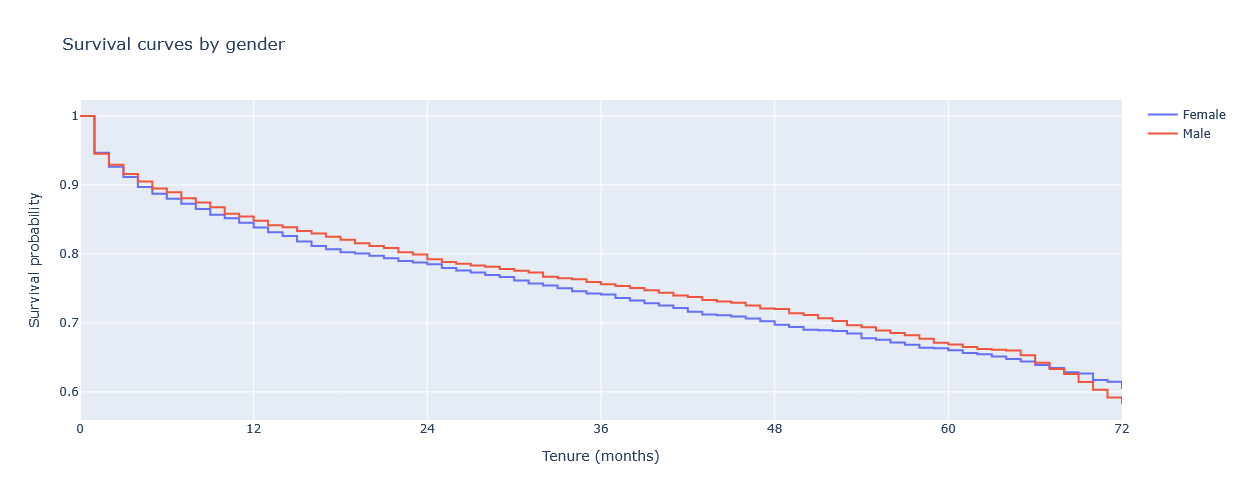

In [196]:
plot_kmf('gender')

In [197]:
result = multivariate_logrank_test(
    df['tenure'],
    df['gender'],
    df['Churn']
)

print(f'Test statistic: {result.test_statistic:.2f}')
print(f'p-value: {result.p_value:.2f}')

Test statistic: 0.53
p-value: 0.47


With a test statistic of $0.53$, and $p=0.47$, there isn't much to celebrate here. There is no significant difference between the survival curves of men and women since we're nowhere near the required threshold of $p\le0.05$

We can move on to other variables. In the interest of streamlining the process, I'll run tests for all the categorical variables and see which ones are the most useful.

In [198]:
def run_logrank_test(df, variable, duration_col='tenure', event_col='Churn'):
    '''
    Returns the test statistic and p-value for the logrank test
    '''
    result = multivariate_logrank_test(
        df[duration_col],
        df[variable],
        df[event_col]
    )

    return {
        'variable': variable,
        'test_statistic': result.test_statistic,
        'p-value': result.p_value
    }

In [199]:
variables = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
             'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
             'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
             'Contract', 'PaperlessBilling', 'PaymentMethod']

results = [run_logrank_test(df, var) for var in variables]
summary = pd.DataFrame(results).sort_values('p-value', ascending=False)
summary

,variable,test_statistic,p-value
4,PhoneService,0.4308185989,0.5115875474
0,gender,0.5257069722,0.4684173508
5,MultipleLines,30.9690356033,0.0000001884
1,SeniorCitizen,109.4896933881,0.0000000000
14,PaperlessBilling,189.5114860901,0.0000000000
3,Dependents,232.6990417089,0.0000000000
11,StreamingTV,368.3074319226,0.0000000000
12,StreamingMovies,378.4261518395,0.0000000000
2,Partner,423.5430816001,0.0000000000
6,InternetService,520.1206081845,0.0000000000


It seems we have a lot of variables that meet the 0.05 threshold. This could mean that we have a lot of highly relevant variables, or it could mean that the threshold of significance is too high. With this many variables, it's likely that some will seem significant just by random chance. To account for this, we'll apply the **Bonferroni correction**. This just means dividing the threshold by the number of variables. This gives us $\frac{0.05}{16}=0.003125$

In [200]:
most_relevant = summary[summary['p-value'] < 0.003125]
most_relevant

,variable,test_statistic,p-value
5,MultipleLines,30.9690356033,0.0000001884
1,SeniorCitizen,109.4896933881,0.0000000000
14,PaperlessBilling,189.5114860901,0.0000000000
3,Dependents,232.6990417089,0.0000000000
11,StreamingTV,368.3074319226,0.0000000000
12,StreamingMovies,378.4261518395,0.0000000000
2,Partner,423.5430816001,0.0000000000
6,InternetService,520.1206081845,0.0000000000
9,DeviceProtection,763.5064140747,0.0000000000
8,OnlineBackup,821.3388247398,0.0000000000


This has only removed two variables from the list. Given the sheer number of variables meeting adjusted relevance threshold, it's likely that a few of these variables are strongly correlated with each other. We can quickly assess this by plotting their correlation coefficients

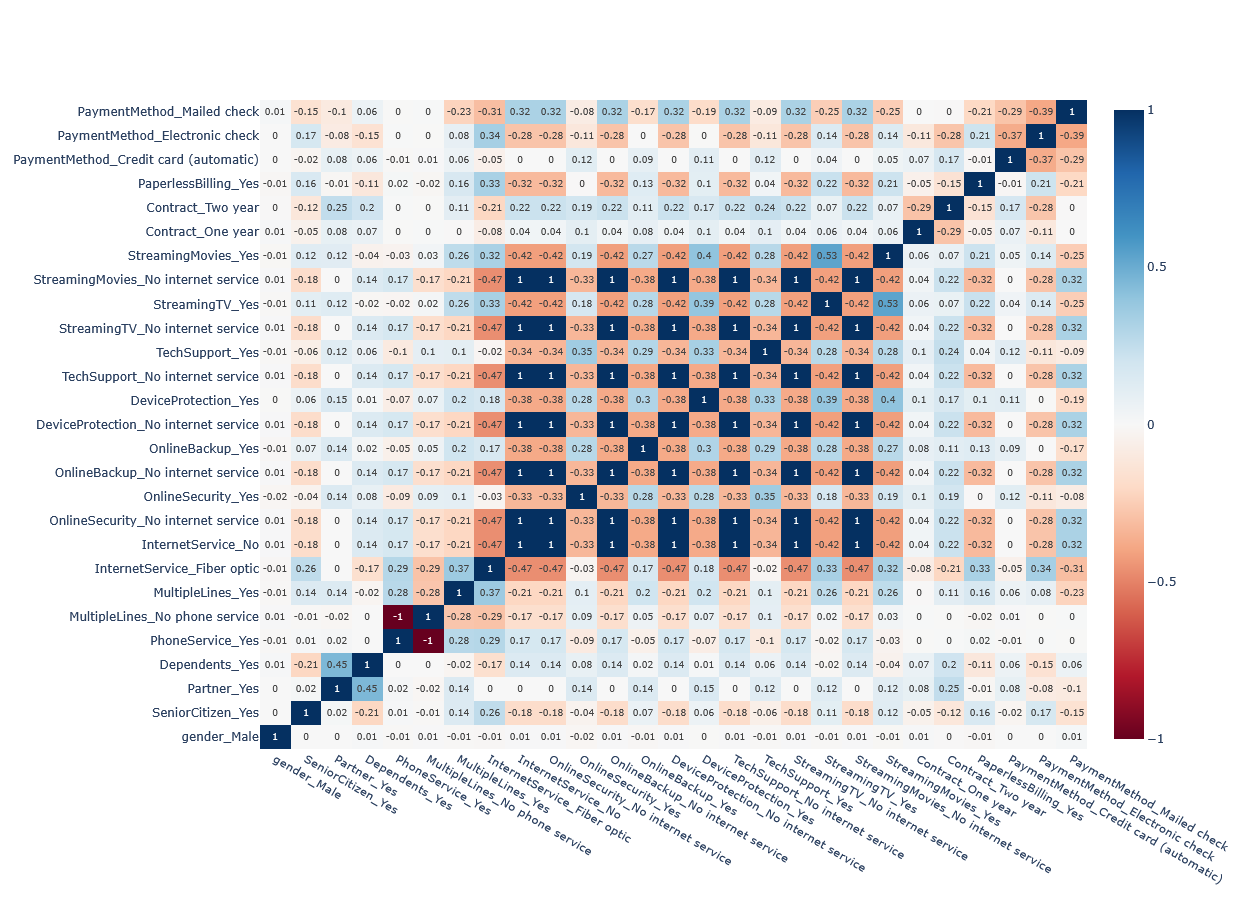

In [201]:
# converting categorical variables into one-hot encoding
X = pd.get_dummies(df[variables], drop_first=True).astype(float)
corr = X.corr()

fig = go.Figure(
    data=go.Heatmap(
        z=corr.values,
        x=corr.columns,
        y=corr.columns,
        colorscale='RdBu',
        zmid=0,
        text=corr.round(2).values,
        texttemplate="%{text}"
    )
)

fig.update_layout(height=900)

fig.show()

There's a clear cluster of variables that have a 1:1 correlation here. In short, the variables dependend on having an internet connection are perfectly correlated with the variable denoting the presence of an internet connection. To keep the model as simple as possible, I'll remove these variables from the dataset.

In [202]:
original_vars = most_relevant['variable'].to_list()
vars_to_exclude = [
    'StreamingMovies', 'StreamingTV', 'DeviceProtection', 'TechSupport',
    'OnlineBackup', 'OnlineSecurity', 'MultipleLines'
]

remaining_vars = [var for var in original_vars if var not in vars_to_exclude]
remaining_vars

['SeniorCitizen',
 'PaperlessBilling',
 'Dependents',
 'Partner',
 'InternetService',
 'PaymentMethod',
 'Contract']

In [203]:
most_relevant[most_relevant['variable'].isin(remaining_vars)]

,variable,test_statistic,p-value
1,SeniorCitizen,109.4896933881,0.0000000000
14,PaperlessBilling,189.5114860901,0.0000000000
3,Dependents,232.6990417089,0.0000000000
2,Partner,423.5430816001,0.0000000000
6,InternetService,520.1206081845,0.0000000000
15,PaymentMethod,865.2394631324,0.0000000000
13,Contract,2352.8725382593,0.0000000000


This is a much more reasonable set of variables. There is still a reasonbly strong correlation between `Partner` and `Dependents`, but not so much that I think it will cause issues.

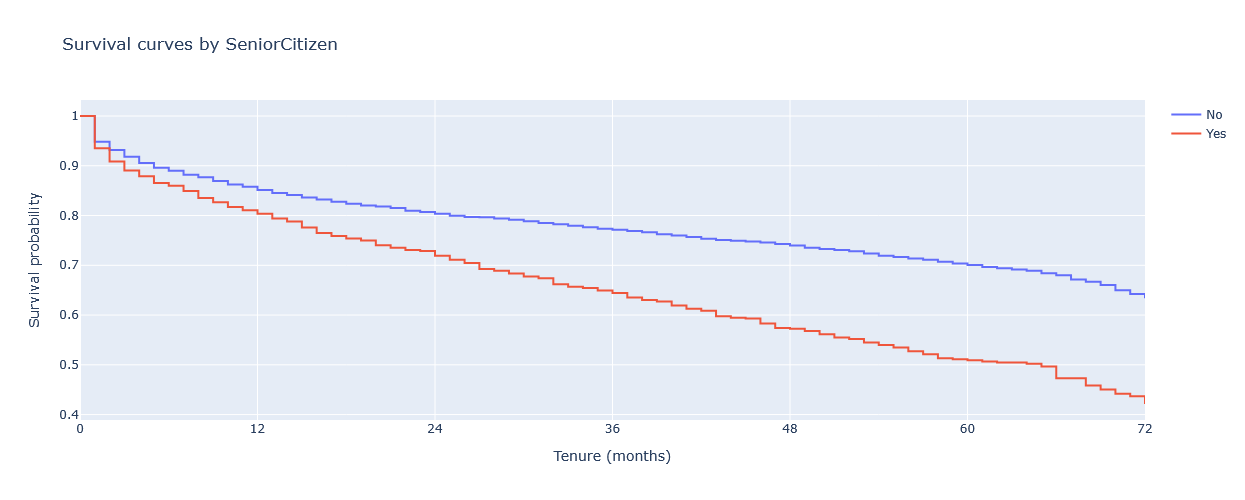

In [204]:
plot_kmf(var='SeniorCitizen')

**Findings**  
Both senior citizens and their younger counterparts have a similar propensity to churn in their first few months, but they diverge from each other after a year or so. Things tend to steady for non-seniors after around 18 months in that their monthly drop-off remains relatively steady. No big changes in the steepness of the curve. While things are relatively constant for seniors as well after 18 months, they have a much larger dropoff in their first 18 months, with only 80% of them remaining after 12 months, compared to 85% of non-seniors. 

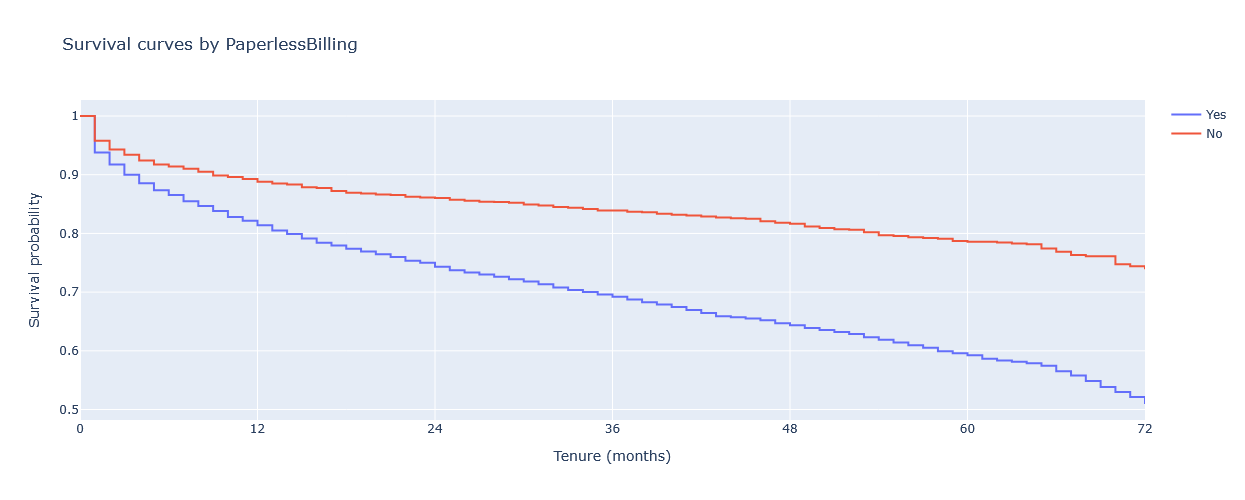

In [205]:
plot_kmf(var='PaperlessBilling')

**Findings**  
Those who use paperless billing are far less likely to stick around after even one year (81% vs 88%) and after two years, the difference is even greater (74% vs 86%).

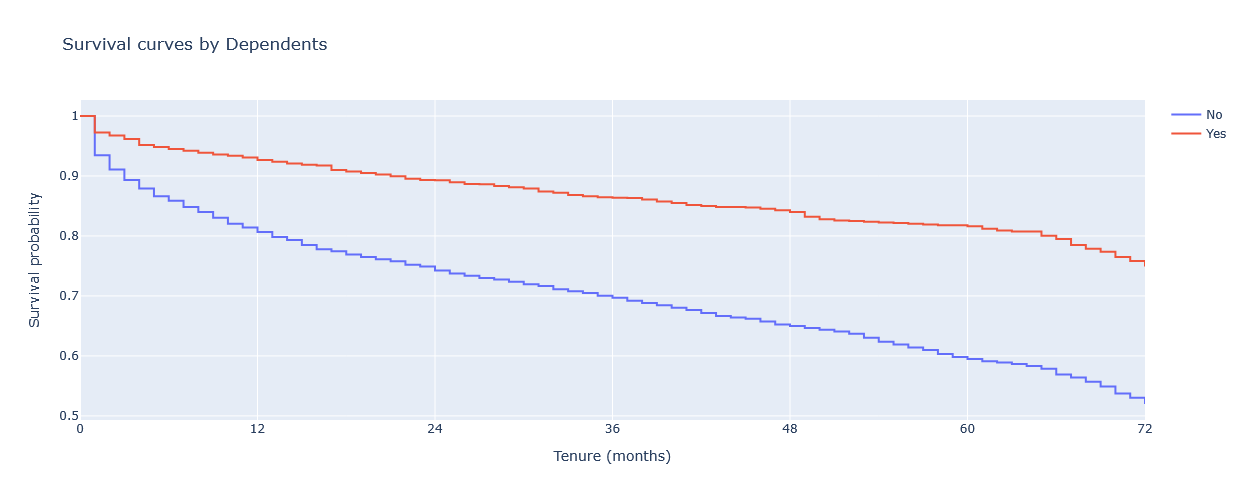

In [208]:
plot_kmf('Dependents')

**Findings**  
There is a _remarkable_ difference between the two groups here. After one year, only 80% of those without dependents remain, compared to 93% of those who do have dependents. After two years, 74% vs 89%. The gap continues to widen over time. This tells us that 

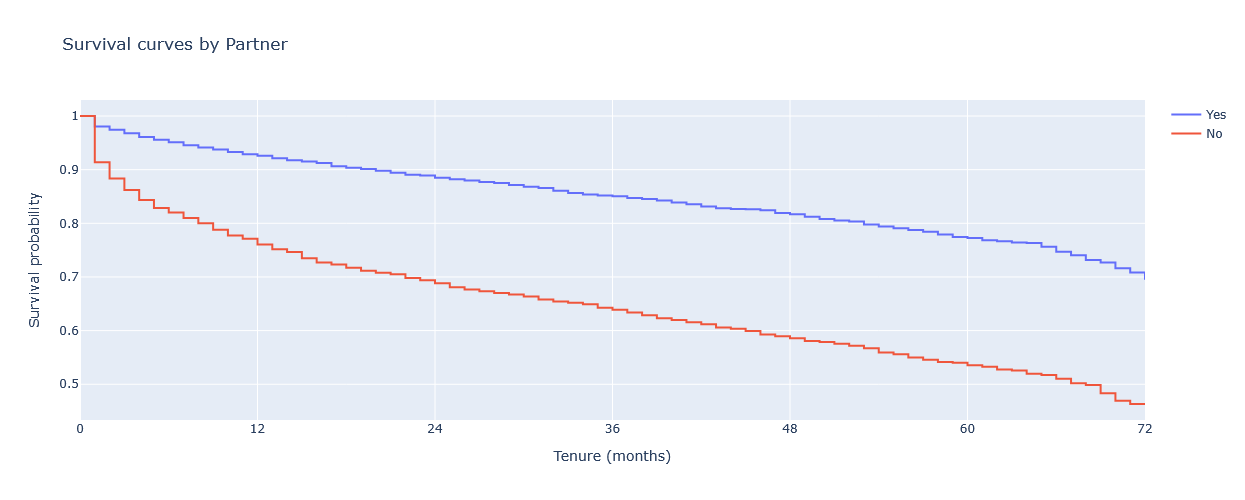

In [209]:
plot_kmf('Partner')

**Findings**  
Holy crap. This is our most effective variable so far. After only three months, there is more than a 10 percentage point (pp) difference between those without a partner and those with a partner (86% vs 96%). This gap widens to 20pp after two years.

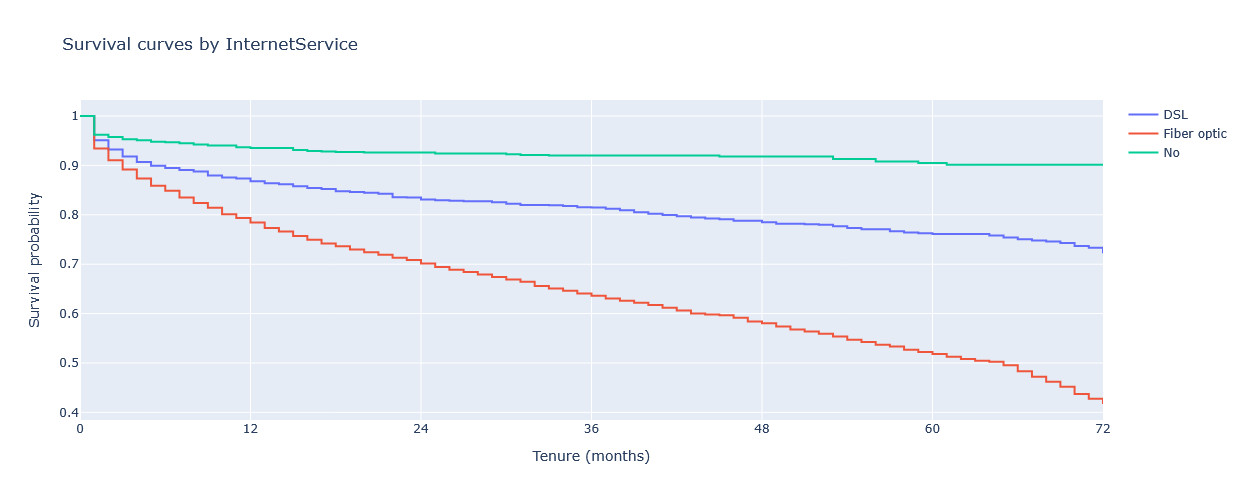

In [210]:
plot_kmf('InternetService')

**Findings**  
Fiber optic is clearly the least sticky of the three options here. It drops to 78% after just one year, and 70% after two years, while maintaining a relatively steep downwards trend. The runner up is DSL, with a reasonably flat curve after dropping to 87% after the first year.  
The clear winning group is users with no internet service. This remains as high as 90% after _six years_ and has the flattest curve of the three. 

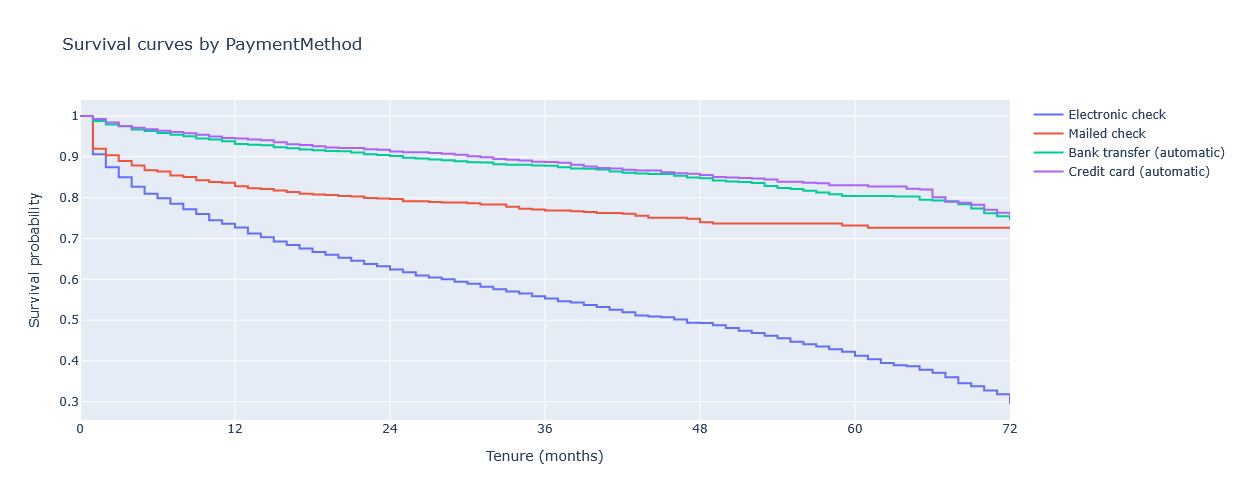

In [211]:
plot_kmf('PaymentMethod')

**Findings**  
This might be one of the least surprising charts in this project. Both of the automatic payment methods show the best (and almost identical) rates of retention, remaining as high as 80-83% after five years.  
Mailed check is our middle child, with a steep dropoff to 83% after the first 12 months, followed by a relatively flat retention rate, dropping to only 73% after five years.  
Electronic check is the payment type with the worst retention rate, dropping to 73% after 12 months, and continuing its descent to 41% after five years.

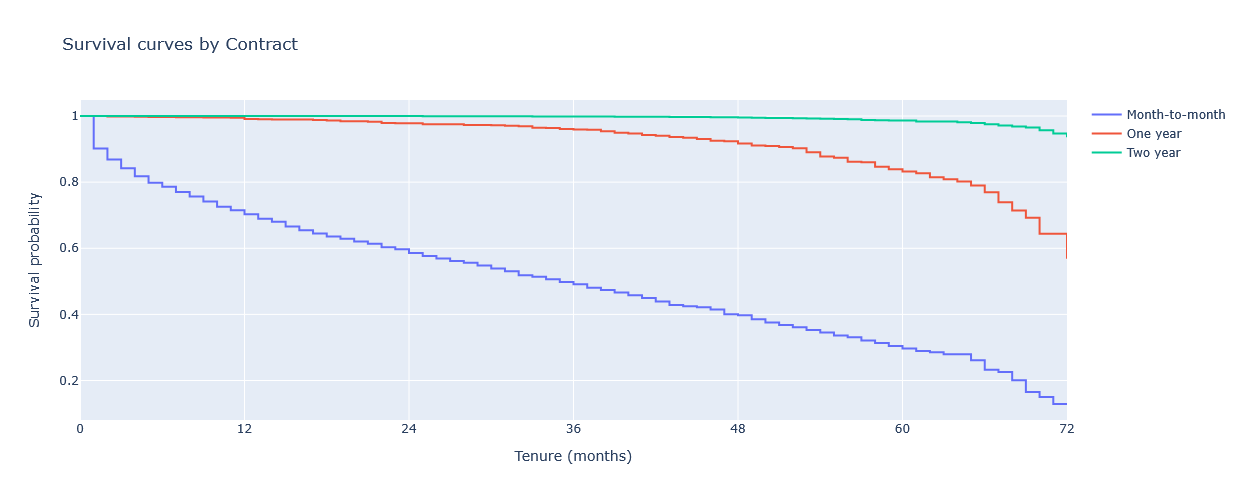

In [213]:
plot_kmf('Contract')

**Findings**  
Our last visual inspection is by far the most obvious one. Customers on a two-year contract tend to stick around for much longer, with their five-year retention at 99%.  
This is less pronounced for the one-year contract, but still positive, as 83% of customers remain after five years.  
Customers on a month-to-month contract are not _nearly_ as likely to stick around. After one year, only 70% remain, and only 59% after two years. After five years, there are only 30% of month-to-month customers remaining